In [1]:
import pandas as pd

Creating dataframes

In [2]:
CQP_1 = pd.read_csv("../Datasets/CQP1.csv", sep=";")
CQP_2 = pd.read_csv("../Datasets/CQP2.csv", sep=";")
CQP_3 = pd.read_csv("../Datasets/CQP3.csv", sep=";")
CQP_4 = pd.read_csv("../Datasets/CQP4.csv", sep=";")
CQP_5 = pd.read_csv("../Datasets/CQP5.csv", sep=";")
CQP_6 = pd.read_csv("../Datasets/CQP6.csv", sep=";")
CQP_7 = pd.read_csv("../Datasets/CQP7.csv", sep=";")
CQP_8 = pd.read_csv("../Datasets/CQP8.csv", sep=";")

Inspecting the data

In [3]:
CQP_1.head()

,word,text_thread_id,Yhteensä,Suomi24 2021–2023: 2021,Suomi24 2021–2023: 2022,Suomi24 2021–2023: 2023
0,Σ,Σ,28.909224,28.128331,29.634402,29.010866
1,hapankaali,16796146,0.061217,0.146402,0.041341,0.000000
2,hedelmä,17969829,0.054884,0.000000,0.000000,0.151615
3,hampurilainen,18191211,0.054884,0.000000,0.000000,0.151615
4,hedelmä,17254127,0.040108,0.000000,0.130912,0.000000


Concatenating all dataframes into one dataframe and removing unnecessary columns

In [4]:
CQP = pd.concat([CQP_1, CQP_2, CQP_3, CQP_4, CQP_5, CQP_6, CQP_7, CQP_8])
CQP = CQP[["word", "text_thread_id"]]

Examining the new dataframe

In [5]:
CQP.head()

,word,text_thread_id
0,Σ,Σ
1,hapankaali,16796146
2,hedelmä,17969829
3,hampurilainen,18191211
4,hedelmä,17254127


In [6]:
CQP.describe()

,word,text_thread_id
count,86736,86736
unique,692,58504
top,viina,16877322
freq,4352,112


In [7]:
print(CQP)

               word text_thread_id
0                 Σ              Σ
1        hapankaali       16796146
2           hedelmä       17969829
3     hampurilainen       18191211
4           hedelmä       17254127
...             ...            ...
7926     täytekakku       17739398
7927     täytekakku       17723722
7928     täytekakku       17716602
7929     täytekakku       17710262
7930     tyrnimarja       18048742

[86736 rows x 2 columns]


Grouping food items based on the thread ID

In [8]:
food_id = CQP.groupby("text_thread_id")["word"].apply(list)
food_id = food_id[food_id.apply(lambda x: len(set(x)) >= 2)]

Inspecting the outcome (Pandas series)

In [9]:
food_id.head()

text_thread_id
10013536             [jauhelihakeitto, pinaattikeitto]
10018155    [jauhelihakeitto, kaurapuuro, perunavelli]
10031585                             [luumu, siirappi]
10041905                       [banaani, maito, mysli]
10049647                             [mehu, punaviini]
Name: word, dtype: object

In [10]:
food_id.describe()

count             12925
unique             8296
top       [hauki, kala]
freq                148
Name: word, dtype: object

In [11]:
type(food_id)

pandas.core.series.Series

Iterating over the Series and then finding foods that appear in the same thread. Additionally, the number of co-occurences is calculated for the edge weight

In [12]:
from itertools import combinations
from collections import Counter

edges = []

for foods in food_id:
    unique_foods = sorted(set(foods))
    edges.extend(combinations(unique_foods, 2))

edge_weights = Counter(edges)

Key is an edge and the value is the edge weight

In [13]:
print(edge_weights)

Counter({('hauki', 'kala'): 299, ('olut', 'viina'): 256, ('kalja', 'olut'): 189, ('kalja', 'viina'): 186, ('olut', 'viini'): 183, ('kala', 'lohi'): 179, ('kala', 'kana'): 178, ('kahvi', 'pulla'): 176, ('kahvi', 'maito'): 166, ('juusto', 'maito'): 153, ('viina', 'viini'): 150, ('ahven', 'kala'): 150, ('mansikka', 'mustikka'): 146, ('kala', 'peruna'): 144, ('peruna', 'porkkana'): 142, ('kalja', 'viini'): 132, ('kahvi', 'kala'): 130, ('kala', 'maito'): 125, ('kebab', 'pizza'): 123, ('kahvi', 'olut'): 122, ('maito', 'peruna'): 121, ('hedelmä', 'viini'): 111, ('kurkku', 'tomaatti'): 109, ('peruna', 'riisi'): 106, ('peruna', 'sipuli'): 103, ('kahvi', 'viina'): 103, ('porkkana', 'sipuli'): 102, ('kahvi', 'suklaa'): 99, ('kala', 'olut'): 96, ('kala', 'silakka'): 95, ('maito', 'olut'): 95, ('juusto', 'kala'): 94, ('hedelmä', 'kala'): 94, ('makkara', 'peruna'): 93, ('juusto', 'kahvi'): 93, ('kana', 'maito'): 92, ('kerma', 'maito'): 87, ('hedelmä', 'omena'): 86, ('kala', 'makkara'): 85, ('makkara

Food-Food network

In [14]:
import networkx as nx

G = nx.Graph()

for (food1, food2), weight in edge_weights.items():
    G.add_edge(food1, food2, weight=weight)

print(G.number_of_nodes(), "Nodes")
print(G.number_of_edges(), "Edges")

675 Nodes
37832 Edges


Visualization

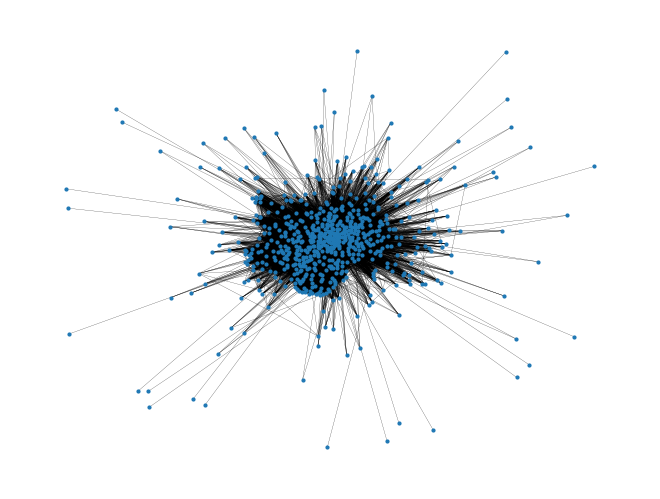

In [21]:
import matplotlib.pyplot as plt

nx.draw_spring(G, node_size=4, width=0.15)
plt.show()

Creating a Gephi file of the graph for extra visualization

In [ ]:
nx.write_gexf(G, "food_network.gexf")